# **Multilabel Classification - Test**

# **Imports**

In [ ]:

from earthscape.utils import *
from earthscape.constants import ES_VERSION_SPLIT_DIR, SMOKE_VERSION_SPLIT_DIR, MODEL_CLF_DIR
from earthscape.models.dataloaders import *
from earthscape.models.sgmapnet import *
from earthscape.models.focal_loss import *
from earthscape.models.training_utils import *

import os
import datetime
import pandas as pd
import geopandas as gpd
import torch
from torch.utils.data import DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# **Setup**

In [2]:
############################################################
# Define parameters for training, validation, and testing
############################################################

# set seed for reproducibility
seed = 111
set_seed(seed)


# dict of informal name (modality) & list of file suffixes
modality_configs = {
    'dem': {
        'channels': ['dem.tif']
        }, 
    # 'aerial': {
    #     'channels': ['aerialr.tif', 'aerialg.tif', 'aerialb.tif']
    #     }
    }


# get normalization parameters for input modalities/channels
norm_stats_path = f"{ES_VERSION_SPLIT_DIR}/train_stats.csv"
modality_configs = get_norm_stats(norm_stats_path, modality_configs)


# list of directories containing patch data
patch_dirs = [
    # f"{DATASET_DIR}/warren/patches", 
    # f"{DATASET_DIR}/howevalley/patches", 
    # f"{DATASET_DIR}/sonora/patches", 
    f"{SMOKE_VERSION_SPLIT_DIR}/patches"
    ]


# get patch IDs & create pytorch datasets...
# training set
train_patch_path = f"{SMOKE_VERSION_SPLIT_DIR}/smoke_train_id.geojson"
train = gpd.read_file(train_patch_path)
train_patch_ids = train['patch_id'].to_list()
train_dataset = EarthScape_Dataset(train_patch_ids, patch_dirs, modality_configs, augment=True)

# validation set
val_patch_path = f"{SMOKE_VERSION_SPLIT_DIR}/smoke_val_id.geojson"
val = gpd.read_file(val_patch_path)
val_patch_ids = val['patch_id'].to_list()
val_dataset = EarthScape_Dataset(val_patch_ids, patch_dirs, modality_configs, augment=False)

# test set
test_patch_path = f"{SMOKE_VERSION_SPLIT_DIR}/smoke_test_id.geojson"
test = gpd.read_file(test_patch_path)
test_patch_ids = test['patch_id'].to_list()
test_dataset = EarthScape_Dataset(test_patch_ids, patch_dirs, modality_configs, augment=False)

# cross-domain test set
cross_patch_path = f"{SMOKE_VERSION_SPLIT_DIR}/smoke_test_cd.geojson"
cross = gpd.read_file(cross_patch_path)
cross_patch_ids = cross['patch_id'].to_list()
cross_dataset = EarthScape_Dataset(cross_patch_ids, patch_dirs, modality_configs, augment=False)


# model hyperparameters & settings...
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 2
num_epochs = 5
encoder = 'resnext'
model = SGMapNet_Classification(modality_configs, encoder, enable_attention=False, embedding_dim=512, num_heads=8, p_attn=0.0, p_resid=0.0).to(device)
optimizer = optim.Adam(model.parameters())


# dataloaders...
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
cross_loader = DataLoader(cross_dataset, batch_size=batch_size, shuffle=False, drop_last=True)


# focal loss...
reduction = 'mean'
gamma = 2.0
alpha = 0.25
alpha = torch.tensor(alpha, dtype=torch.float32).view(1, -1).to(device)
criterion = FocalLoss(alpha=alpha, gamma=gamma, reduction=reduction).to(device)


# create output directory...
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
modality_str = '_'.join(list(modality_configs.keys()))
model_name = f"{encoder}_{modality_str}_{timestamp}"
output_dir = f"{MODEL_CLF_DIR}/{model_name}"
if not os.path.isdir(output_dir):
    os.makedirs(output_dir)


# log metadata
training_log(model_name, output_dir, seed,
             train_patch_ids, val_patch_ids, test_patch_ids, cross_patch_ids,
             modality_configs, 
             batch_size, num_epochs, optimizer, criterion, model)

# **DataLoader Test**

In [3]:
###################################
# Example DataLoader Information
###################################

# extract example
example = next(iter(val_loader))

# print data report
for modality in example.keys():
    print(modality)
    print(f"{type(example[modality])}  |  {example[modality].dtype}  |  {example[modality].shape}  |  {example[modality].min()}  |  {example[modality].max()}")

label
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([2, 7])  |  0.0  |  1.0
dem
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([2, 1, 256, 256])  |  -2.1835010051727295  |  2.6286470890045166


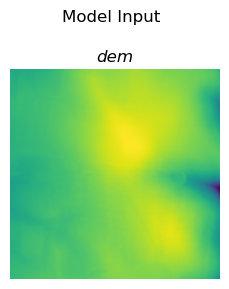

In [4]:
###################################
# Example DataLoader Visualization
###################################

# extract total number of channels to plot...
num_channels = 0
for k,v in example.items():
    if not 'label' in k:
        num_channels += v.shape[1]

# define number of columns & rows...
ncols = min(4, num_channels)
nrows = (num_channels // ncols) + 1

# setup figure...
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 3*nrows))
ax = ax.ravel()

# plot channels separately...
idx = 0
for k,v in example.items():
    if 'label' in k:
        label = v.detach().numpy()[0]
        fig.suptitle(f"Model Input")
    else:
        v_sample = v.detach().numpy()[0]
        for c in range(v_sample.shape[0]):
            img = v_sample[c]
            min_val = img.min()
            max_val = img.max()
            img = (img - min_val) / (max_val - min_val + 1e-8)
            ax[idx].imshow(img)
            ax[idx].set_axis_off()
            ax[idx].set_title(k, style='italic')
            idx += 1

# remove any extra subplot axes...
for j in range(idx, len(ax)):
    fig.delaxes(ax[j])

plt.show()

# **Training**

In [5]:
###############
# Train Model
###############

df_train = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs, output_dir)

Epoch 1
TRAINING   -- Loss: 0.0400  |  Accuracy: 61.90%  |  Time: 0.02 mins.
VALIDATION -- Loss: 0.0363  |  Accuracy: 71.43%  |  Time: 0.0 mins.
New best model saved!


Epoch 2
TRAINING   -- Loss: 0.0264  |  Accuracy: 83.33%  |  Time: 0.02 mins.
VALIDATION -- Loss: 0.0400  |  Accuracy: 71.43%  |  Time: 0.0 mins.


Epoch 3
TRAINING   -- Loss: 0.0298  |  Accuracy: 71.43%  |  Time: 0.02 mins.
VALIDATION -- Loss: 0.0445  |  Accuracy: 61.90%  |  Time: 0.0 mins.


Epoch 4
TRAINING   -- Loss: 0.0233  |  Accuracy: 88.10%  |  Time: 0.02 mins.
VALIDATION -- Loss: 0.0668  |  Accuracy: 64.29%  |  Time: 0.0 mins.


Epoch 5
TRAINING   -- Loss: 0.0202  |  Accuracy: 88.10%  |  Time: 0.02 mins.
VALIDATION -- Loss: 0.0796  |  Accuracy: 69.05%  |  Time: 0.0 mins.




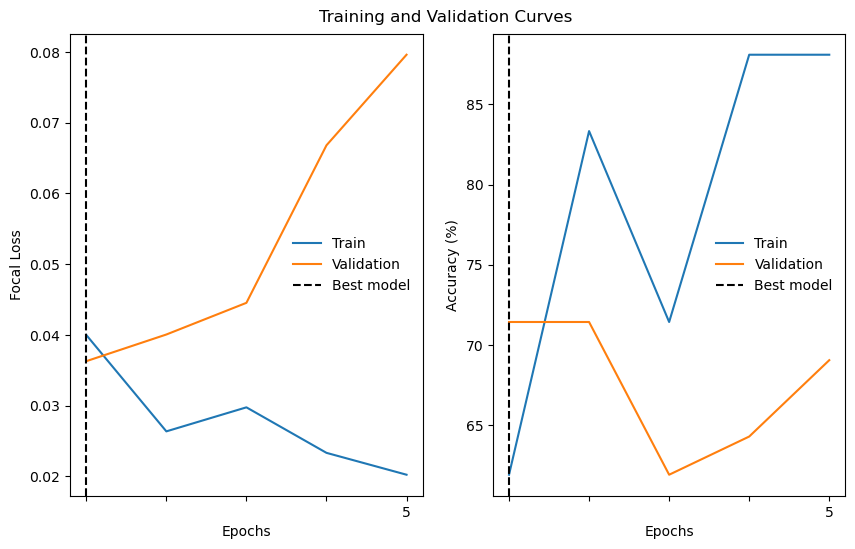

In [6]:
#########################
# Plot Training Curves
#########################

fig = plot_training_curves(df_train, output_dir)

fig.savefig(f"{output_dir}/training_curves.png", dpi=300, bbox_inches='tight', pad_inches=0)

# **Inference**

## *Threshold Tuning*

In [7]:
#########################################################
# Tune Prediction Thresholds with F1 on Validation Set
#########################################################

# load model...
model_path = glob.glob(f"{output_dir}/best_loss_epoch*.pth")[0]
state_dict = torch.load(model_path, map_location=device, weights_only=False)
model.load_state_dict(state_dict)

# optimize thresholds
optimal_thresholds = calculate_optimal_thresholds(model, val_loader, device)

## *In-domain Inference*

In [ ]:
#############################################
# Inference & Global Performance Metrics
#############################################

# inference...
probabilities, targets = test_model(model, test_loader, device)

# global performance metrics
df_global = calculate_global_metrics(targets, probabilities, thresholds=optimal_thresholds)
df_global.to_csv(f"{output_dir}/id_global.csv", index=False)

df_global.head()

,Precision,Recall,F1,AUC,mAP,Precision (Wt.),Recall (Wt.),F1 (Wt.),AUC (Wt.),mAP (Wt.),Accuracy (Micro)
0,0.561905,1.0,0.67987,NaN,0.793452,0.736508,1.0,0.823593,NaN,0.895238,0.690476


In [ ]:
###################################
# Per-Class Performance Metrics
###################################

# class performance metrics
df_class = calculate_class_metrics(targets, probabilities, thresholds=optimal_thresholds)
df_class.to_csv(f"{output_dir}/id_class.csv", index=False)

df_class.head(10)

,Class,True,Predicted,Accuracy,Precision,Recall,F1,AUC,AP
0,af1 (0.35),3.0,5.0,0.666667,0.600000,1.0,0.750000,0.888889,0.916667
1,Qal (0.56),5.0,6.0,0.833333,0.833333,1.0,0.909091,1.000000,1.000000
2,Qaf (0.44),1.0,4.0,0.500000,0.250000,1.0,0.400000,0.800000,0.500000
3,Qat (0.42),1.0,3.0,0.666667,0.333333,1.0,0.500000,0.600000,0.333333
4,Qc (0.62),4.0,6.0,0.666667,0.666667,1.0,0.800000,0.625000,0.804167
5,Qca (0.51),1.0,4.0,0.500000,0.250000,1.0,0.400000,1.000000,1.000000
6,Qr (0.58),6.0,6.0,1.000000,1.000000,1.0,1.000000,NaN,1.000000


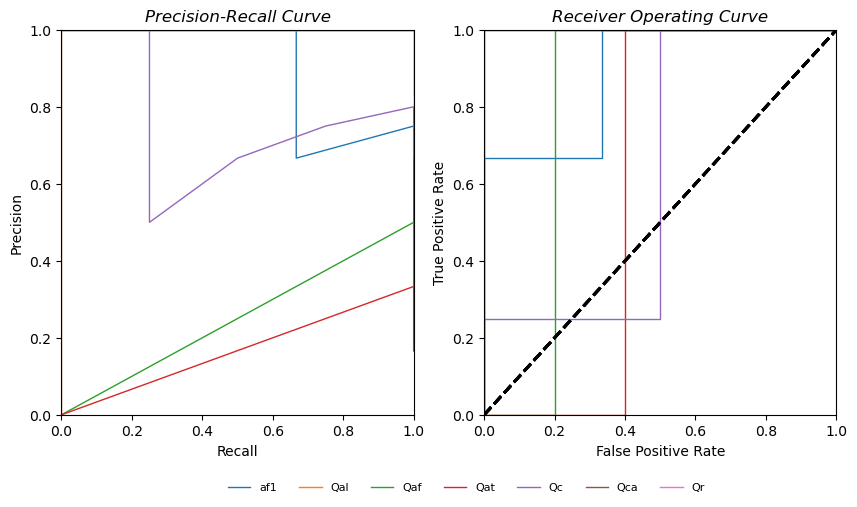

In [13]:
########################################
# Per-Class Performance Visualization
########################################

# precision-recall curve
fig = plot_label_pr_roc_curves(targets, probabilities)
fig.savefig(f"{output_dir}/id_pr_curves.jpg")

## *Cross-domain Inference*

In [15]:
#############################################
# Inference & Global Performance Metrics
#############################################

# inference...
probabilities, targets = test_model(model, cross_loader, device)

# global performance metrics
df_cross_global = calculate_global_metrics(targets, probabilities, thresholds=optimal_thresholds)
df_cross_global.to_csv(f"{output_dir}/cd_global.csv", index=False)

df_cross_global.head()

,Precision,Recall,F1,AUC,mAP,Precision (Wt.),Recall (Wt.),F1 (Wt.),AUC (Wt.),mAP (Wt.),Accuracy (Micro)
0,0.397619,0.542857,0.434632,NaN,0.582778,0.618333,0.7,0.631061,NaN,0.718333,0.452381


In [16]:
###################################
# Per-Class Performance Metrics
###################################

# class performance metrics
df_cross_class = calculate_class_metrics(targets, probabilities, thresholds=optimal_thresholds)
df_cross_class.to_csv(f"{output_dir}/cd_class.csv", index=False)

df_cross_class.head(10)

,Class,True,Predicted,Accuracy,Precision,Recall,F1,AUC,AP
0,af1 (0.35),2.0,4.0,0.333333,0.250000,0.500000,0.333333,0.250000,0.325000
1,Qal (0.56),5.0,5.0,0.666667,0.800000,0.800000,0.800000,0.200000,0.810000
2,Qaf (0.44),1.0,5.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.166667
3,Qat (0.42),1.0,1.0,0.666667,0.000000,0.000000,0.000000,0.800000,0.500000
4,Qc (0.62),3.0,5.0,0.333333,0.400000,0.666667,0.500000,0.222222,0.444444
5,Qca (0.51),2.0,6.0,0.333333,0.333333,1.000000,0.500000,0.875000,0.833333
6,Qr (0.58),6.0,5.0,0.833333,1.000000,0.833333,0.909091,NaN,1.000000


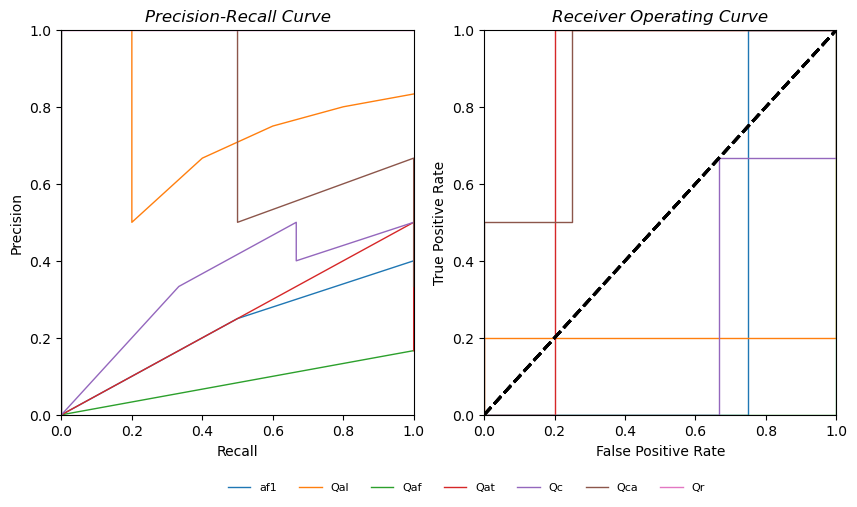

In [17]:
########################################
# Per-Class Performance Visualization
########################################

# precision-recall curve
fig = plot_label_pr_roc_curves(targets, probabilities)
fig.savefig(f"{output_dir}/cd_pr_curves.jpg")